**Simple Linear Regression (Single Feature)**  
- The Task: Find a simple dataset with one continuous feature and one target (e.g., predicting a student's test score based on hours studied).
- Objectives: 
- Split the data into training and testing sets.
- Use sklearn.linear_model.LinearRegression to train the model.
- Create a scatter plot of the test data and overlay the predicted line of best fit.

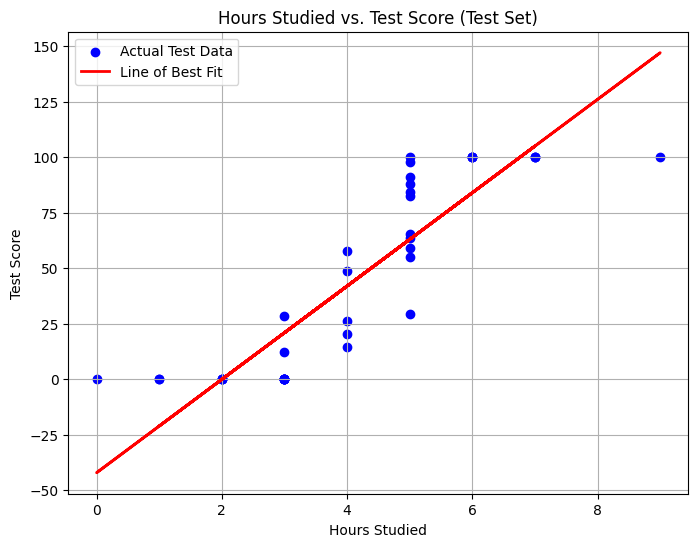

--- Part 1: Simple Linear Regression Metrics ---
Slope (Coefficient): 21.0275
Intercept: -42.2203
R² Score: 0.7570


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the custom dataset
df = pd.read_csv('study_hour.csv')

# Define feature (X) and target (y)
X = df[['Hours_Studied']]
y = df['Test_Score']

# 2. Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Simple Linear Regression model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = simple_model.predict(X_test)

# 4. Plot the test data and the line of best fit
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Line of Best Fit')
plt.title('Hours Studied vs. Test Score (Test Set)')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.legend()
plt.grid(True)
plt.show()

# Evaluation Metrics
print("--- Part 1: Simple Linear Regression Metrics ---")
print(f"Slope (Coefficient): {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

**Multiple Linear Regression & Feature Interpretation**
- Dataset: from sklearn.datasets import fetch_california_housing
- The Task: Use a multi-featured dataset like the California Housing Dataset.
- Objectives:
- Perform basic Exploratory Data Analysis (EDA) to check for correlations between features.
- Train a Multiple Linear Regression model.
- Extract and interpret the model's coefficients. Which features have the strongest positive or negative impact on the target variable?

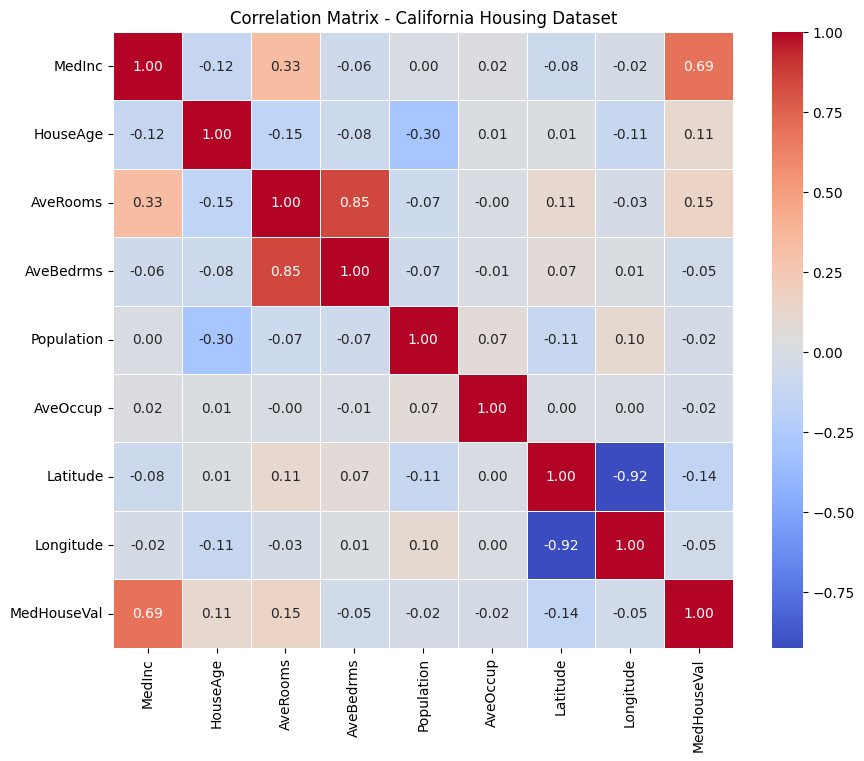


--- Part 2: Multiple Linear Regression Coefficients (Standardized) ---
   Feature  Coefficient
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929

--- Coefficient Interpretation ---
Strongest Positive Impact: MedInc (0.8544)
Strongest Negative Impact: Latitude (-0.8969)


In [2]:
import seaborn as sns
from sklearn.datasets import fetch_california_housing
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Load the California Housing Dataset
california = fetch_california_housing(as_frame=True)
df_housing = california.frame

# 2. Exploratory Data Analysis (EDA) - Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df_housing.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix - California Housing Dataset')
plt.show()

# 3. Train a Multiple Linear Regression Model
X_multi = df_housing.drop(columns=['MedHouseVal'])
y_multi = df_housing['MedHouseVal']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Scale features to make coefficient sizes directly comparable
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled = scaler.transform(X_test_m)

multi_model = LinearRegression()
multi_model.fit(X_train_scaled, y_train_m)

# 4. Extract and Interpret Coefficients
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Part 2: Multiple Linear Regression Coefficients (Standardized) ---")
print(coefficients.to_string(index=False))

print("\n--- Coefficient Interpretation ---")
print(f"Strongest Positive Impact: {coefficients.iloc[0]['Feature']} ({coefficients.iloc[0]['Coefficient']:.4f})")
print(f"Strongest Negative Impact: {coefficients.iloc[-1]['Feature']} ({coefficients.iloc[-1]['Coefficient']:.4f})")